In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "2"
os.environ["OMP_NUM_THREADS"] = "2"

In [2]:
from datasets import load_dataset, DownloadConfig
from itertools import islice

download_config = DownloadConfig(
    local_files_only=True,
    cache_dir=".cache",   # optional
)

def batch_iterator(iterable, batch_size):
    iterator = iter(iterable)

    while True:
        batch = list(islice(iterator, batch_size))

        if not batch:
            break

        yield batch

LANGS = ['af_za', 'am_et', 'ar_eg', 'ast_es', 'az_az', 'be_by', 'bg_bg', 'bn_in', 'ca_es', 'ceb_ph', 'ckb_iq', 'cmn_hans_cn', 'cs_cz', 'cy_gb', 'da_dk', 'de_de', 'el_gr', 'en_us', 'es_419', 'et_ee', 'fa_ir', 'ff_sn', 'fi_fi', 'fr_fr', 'ga_ie', 'gl_es', 'ha_ng', 'he_il', 'hi_in', 'hr_hr', 'hu_hu', 'hy_am', 'id_id', 'it_it', 'ja_jp', 'jv_id', 'ka_ge', 'kk_kz', 'km_kh', 'kn_in', 'ko_kr', 'ky_kg', 'lg_ug', 'lo_la', 'lt_lt', 'lv_lv', 'mi_nz', 'mk_mk', 'ml_in', 'mn_mn', 'mr_in', 'ms_my', 'mt_mt', 'my_mm', 'nb_no', 'ne_np', 'nl_nl', 'ny_mw', 'om_et', 'or_in', 'pa_in', 'pl_pl', 'ps_af', 'pt_br', 'ro_ro', 'ru_ru', 'sl_si', 'sn_zw', 'so_so', 'sv_se', 'sw_ke', 'ta_in', 'te_in', 'tg_tj', 'th_th', 'tr_tr', 'uk_ua', 'ur_pk', 'uz_uz', 'vi_vn', 'wo_sn', 'xh_za', 'yo_ng', 'yue_hant_hk', 'zu_za']
#LANGS = LANGS[:10]

/localscratch/nnsfn01/anaconda3/envs/north_caucasus/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [148]:
import numpy as np
import torch
from tqdm import tqdm
import parselmouth
from parselmouth.praat import call
from transformers import Wav2Vec2Model, Wav2Vec2Processor, Wav2Vec2FeatureExtractor
import json
from collections import defaultdict

# -----------------------------
# CONFIG
# -----------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SAMPLE_RATE = 16000
MAX_FRAMES = 10_000   # subsample for clustering
N_CLUSTERS = 50         # tune once (50–200 typical)
BATCH_SIZE = 2
LAYER = 14
MODEL = "facebook/mms-300m"
# -----------------------------
# LOAD MODEL
# -----------------------------
processor = Wav2Vec2FeatureExtractor.from_pretrained(MODEL)
model = Wav2Vec2Model.from_pretrained(MODEL).to(DEVICE)
model.eval()

# -----------------------------
# TEXTGRID PARSING
# -----------------------------


def load_textgrid_phones(tg_path, tier_name="phones"):
    tg = parselmouth.read(tg_path)

    n_tiers = call(tg, "Get number of tiers")

    for i in range(1, n_tiers + 1):
        name = call(tg, "Get tier name", i)
        if name == tier_name:
            tier_index = i
            break
    else:
        raise ValueError(f"{tier_name} tier not found")

    intervals = []
    n_intervals = call(tg, "Get number of intervals", tier_index)

    for j in range(1, n_intervals + 1):
        start = call(tg, "Get start time of interval", tier_index, j)
        end = call(tg, "Get end time of interval", tier_index, j)
        label = call(tg, "Get label of interval", tier_index, j)

        if label.strip() == "":
            label = "sil"

        intervals.append((start, end, label))

    return intervals


# -----------------------------
# EXTRACT EMBEDDINGS
# -----------------------------
@torch.no_grad()
def extract_embeddings_batch(audios):
    results = []

    inputs = processor(
        audios,
        sampling_rate=SAMPLE_RATE,
        return_tensors="pt",
        padding=True
    )

    input_values = inputs.input_values.to(DEVICE)
    attention_mask = inputs.attention_mask.to(DEVICE)
    outputs = model(input_values, attention_mask=attention_mask, output_hidden_states=True)
    hidden = torch.stack(outputs.hidden_states[12:16]).mean(0)
    # sample lengths
    input_lengths = attention_mask.sum(-1).cpu().numpy()

    # exact wav2vec2 frame lengths
    frame_lengths = model._get_feat_extract_output_lengths(torch.tensor(input_lengths)).cpu().numpy()

    for i in range(len(audios)):
        
        num_samples = int(input_lengths[i])
        duration = num_samples / SAMPLE_RATE
        num_frames = int(frame_lengths[i])
        
        emb = hidden[i, :num_frames].cpu().numpy()
        
        # frame timestamps
        frame_times = np.linspace(0,duration,num_frames,endpoint=False)

        results.append((emb, frame_times))

    return results

In [191]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import normalized_mutual_info_score

SAMPLE_SIZE = 50
# -----------------------------
# MAP FRAMES TO PHONEMES
# -----------------------------
def assign_labels_to_frames(frame_times, intervals):
    labels = []
    j = 0
    for t in frame_times:
        while j < len(intervals) - 1 and t > intervals[j][1]:
            j += 1
        labels.append(intervals[j][2])
    return labels
    
def compute_nmi_for_language(lang, align_dir):
    tg_roots = [os.path.join(align_dir, lang)]
    if 'mfa' in align_dir:
        tg_root = tg_roots[0]
        tg_roots = [os.path.join(tg_root, f) for f in os.listdir(tg_root) if os.path.exists(os.path.join(tg_root, f))]

    if not os.path.exists(tg_roots[0]):
        print(f"{tg_root} doesn't exist!")

    test_dataset = load_dataset("fleurs", lang, split='test', streaming=True, download_config=download_config, trust_remote_code=True)
    test_dataset = test_dataset.shuffle(buffer_size= 500).take(SAMPLE_SIZE)


    all_embeddings = []
    all_labels = []

    for batch in batch_iterator(test_dataset, batch_size=BATCH_SIZE):
        # audio arrays
        audios = [x["audio"]["array"][:360000] for x in batch]
        batch_results = extract_embeddings_batch(audios)

        wav_files = [os.path.basename(x["audio"]["path"]) for x in batch]
        tg_paths = []

        for wav_file in wav_files:
            path_exists = False
            for tg_root in tg_roots:
                tg_path = os.path.join(tg_root, os.path.splitext(wav_file)[0] + ".TextGrid")
    
                if os.path.exists(tg_path):
                    tg_paths.append(tg_path)
                    path_exists = True
                    break
            if not path_exists:
                print(f"{tg_path} doesn't exist!")
                tg_paths.append(None)
 

        for (emb, frame_times), tg_path in zip(batch_results, tg_paths):
            if tg_path:
                intervals = load_textgrid_phones(tg_path)
                labels = assign_labels_to_frames(frame_times, intervals)
    
                all_embeddings.append(emb)
                all_labels.extend(labels)


    if len(all_embeddings) == 0:
        return None

    X = np.concatenate(all_embeddings, axis=0)
    y = np.array(all_labels)

    # stratified subsample with sqrt-frequency balancing
    if len(X) > MAX_FRAMES:
        label_to_indices = defaultdict(list)
    
        for i, label in enumerate(y):
            label_to_indices[label].append(i)
    
        freqs = {
            label: len(indices)
            for label, indices in label_to_indices.items()
        }
    
        weights = {
            label: np.sqrt(freq)
            for label, freq in freqs.items()
        }
    
        total_weight = sum(weights.values())
        selected = []
    
        for label, indices in label_to_indices.items():
            n = int(MAX_FRAMES * weights[label] / total_weight)
            n = min(n, len(indices))
    
            chosen = np.random.choice(indices, n, replace=False)
            selected.extend(chosen)
    
        selected = np.array(selected)
    
        X = X[selected]
        y = y[selected]

    # normalize
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms[norms == 0] = 1
    X = X / norms

    X = X.astype(np.float16)

    kmeans = MiniBatchKMeans(n_clusters=N_CLUSTERS, batch_size=1000)
    cluster_ids = kmeans.fit_predict(X)

    nmi = normalized_mutual_info_score(y, cluster_ids)

    return nmi

# -----------------------------
# RUN FOR ALL LANGUAGES
# -----------------------------
def run_all_ph(align_dir):
    results = {}
    for lang in tqdm(LANGS):
        nmi = compute_nmi_for_language(lang, align_dir)
        results[lang] = nmi if nmi else 0

    return results

if __name__ == "__main__":
    paths = ["alignments/mms-300m-ipa/", "alignments/random/", "alignments/mfa/", "alignments/w2v2-lv-60-espeak-ipa/"]
    for path in paths:
        print(f"Evaluating {path} ...")
        results = run_all_ph(path)
        output_path = os.path.join("results", os.path.basename(path) if path[-1] != '/' else os.path.basename(path[:-1]))
        os.makedirs(output_path, exist_ok=True)
        results = {k: round(float(v),3) for k,v in results.items()}
        with open(os.path.join(output_path, "nmi.json"), 'w') as fp:
            json.dump(results, fp, indent=4)


Evaluating alignments/mms-300m-ipa/ ...


100%|███████████████████████████████████████████| 85/85 [16:45<00:00, 11.83s/it]


Evaluating alignments/random/ ...


100%|███████████████████████████████████████████| 85/85 [16:03<00:00, 11.33s/it]


Evaluating alignments/mfa/ ...


...

 99%|██████████████████████████████████████████▍| 84/85 [14:41<00:11, 11.46s/it]

alignments/mfa/zu_za/MALE/18390844154496102011.TextGrid doesn't exist!
alignments/mfa/zu_za/MALE/14423993318256884114.TextGrid doesn't exist!
alignments/mfa/zu_za/MALE/15299141230655611291.TextGrid doesn't exist!


100%|███████████████████████████████████████████| 85/85 [14:54<00:00, 10.52s/it]


Evaluating alignments/w2v2-lv-60-espeak-ipa/ ...


100%|███████████████████████████████████████████| 85/85 [16:49<00:00, 11.88s/it]


In [192]:
from collections import defaultdict
from fastdtw import fastdtw
from scipy.spatial.distance import cosine

MIN_OCC=3
MAX_WORDS=200
MAX_PAIRS=10
POOL=2
SAMPLE_SIZE=200

def pool_emb(x, k=POOL):
    n=len(x)//k
    if n==0: return x
    return x[:n*k].reshape(n,k,-1).mean(1)

def crop_frames(emb, frame_times, start, end):
    idx=(frame_times>=start)&(frame_times<=end)
    return emb[idx]

def dtw_sim(x,y):
    if len(x)<2 or len(y)<2: return None
    x=x/np.maximum(np.linalg.norm(x,axis=1,keepdims=True),1e-8)
    y=y/np.maximum(np.linalg.norm(y,axis=1,keepdims=True),1e-8)
    x,y=pool_emb(x),pool_emb(y)
    distance, path =fastdtw(x,y,dist=cosine)
    return 1 - distance/len(path)

def compute_word_score_for_language(lang, align_dir):
    tg_roots=[os.path.join(align_dir,lang)]
    if 'mfa' in align_dir:
        tg_root=tg_roots[0]
        tg_roots=[os.path.join(tg_root,f) for f in os.listdir(tg_root) if os.path.exists(os.path.join(tg_root,f))]

    test_dataset=load_dataset("fleurs",lang,split='test', streaming=True, download_config=download_config,trust_remote_code=True)
    test_dataset=test_dataset.shuffle(buffer_size=500).take(SAMPLE_SIZE)

    word2embs=defaultdict(list)

    for batch in batch_iterator(test_dataset,batch_size=BATCH_SIZE):
        audios=[x["audio"]["array"][:360000] for x in batch]
        batch_results=extract_embeddings_batch(audios)
        wav_files=[os.path.basename(x["audio"]["path"]) for x in batch]
        tg_paths=[]

        for wav_file in wav_files:
            found=None
            for tg_root in tg_roots:
                tg_path=os.path.join(tg_root,os.path.splitext(wav_file)[0]+".TextGrid")
                if os.path.exists(tg_path):
                    found=tg_path
                    break
            tg_paths.append(found)

        for (emb,frame_times),tg_path in zip(batch_results,tg_paths):
            if tg_path is None: continue
            intervals=load_textgrid_phones(tg_path,tier_name="words")

            for start,end,label in intervals:
                label=label.strip().lower()
                if not label or label in ['sp','sil','<unk>']: continue
                wemb=crop_frames(emb,frame_times,start,end)
                if len(wemb)>=4: word2embs[label].append(wemb)

    pos_sims=[]
    neg_sims=[]
    
    vocab=[w for w,v in word2embs.items() if len(v)>=MIN_OCC]
    vocab=sorted(vocab,key=lambda x:len(word2embs[x]),reverse=True)[:MAX_WORDS]

    for word in vocab:
        embs=word2embs[word]
        pairs=0

        for i in range(len(embs)):
            for j in range(i+1,len(embs)):
                sim=dtw_sim(embs[i],embs[j])
                if sim is not None: pos_sims.append(sim)
                pairs+=1
                if pairs>=MAX_PAIRS: break
            if pairs>=MAX_PAIRS: break

        neg_words=np.random.choice(vocab,min(5,len(vocab)),replace=False)

        for nw in neg_words:
            if nw == word:
                continue
        
            x = embs[np.random.randint(len(embs))]
            y = word2embs[nw][np.random.randint(len(word2embs[nw]))]
        
            sim = dtw_sim(x, y)
        
            if sim is not None:
                neg_sims.append(sim)

    if len(pos_sims)==0 or len(neg_sims)==0: return None

    return {
        "positive": float(np.mean(pos_sims)),
        "negative": float(np.mean(neg_sims)),
        "wacs": float(np.mean(pos_sims)-np.mean(neg_sims))
    }

def run_all_wr(align_dir):
    results={}
    for lang in tqdm(LANGS):
        results[lang]=compute_word_score_for_language(lang,align_dir)
    return results

if __name__=="__main__":
    paths=["alignments/random/", "alignments/mfa/", "alignments/mms-300m-ipa/", "alignments/w2v2-lv-60-espeak-ipa/"]

    for path in paths:
        print(f"Evaluating {path} ...")
        results=run_all_wr(path)

        output_path=os.path.join("results",os.path.basename(path[:-1] if path[-1]=='/' else path))
        os.makedirs(output_path,exist_ok=True)

        with open(os.path.join(output_path,"wacs.json"),"w") as fp:
            json.dump(results,fp,indent=4)

Evaluating alignments/random/ ...


100%|███████████████████████████████████████████| 85/85 [43:05<00:00, 30.42s/it]


Evaluating alignments/mfa/ ...


100%|███████████████████████████████████████████| 85/85 [36:56<00:00, 26.08s/it]


Evaluating alignments/mms-300m-ipa/ ...


100%|███████████████████████████████████████████| 85/85 [40:46<00:00, 28.79s/it]


Evaluating alignments/w2v2-lv-60-espeak-ipa/ ...


100%|███████████████████████████████████████████| 85/85 [40:44<00:00, 28.76s/it]


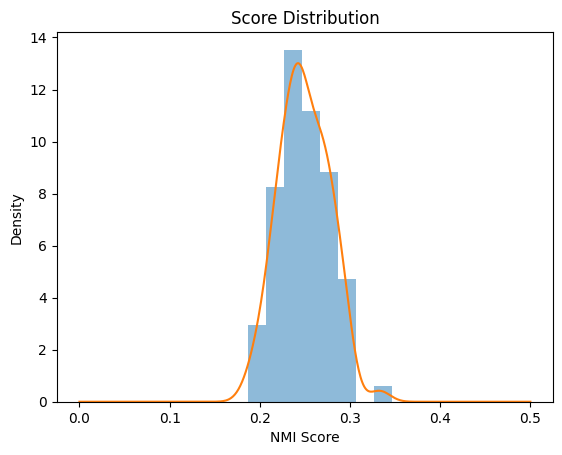

In [208]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
import json

with open("results/mms-300m-ipa/nmi.json", 'r') as fp:
    results = json.load(fp)


scores = list(results.values())
scores = np.array([sc for sc in scores if sc])
plt.figure()

# choose bin width
bin_width = 0.02

# compute bins from min/max
bins = np.arange(scores.min(), scores.max() + bin_width, bin_width)

plt.hist(scores, bins=bins, density=True, alpha=0.5)

# KDE curve
kde = gaussian_kde(scores)
x = np.linspace(0.00, 0.50, 500)
plt.plot(x, kde(x))

plt.xlabel("NMI Score")
plt.ylabel("Density")
plt.title("Score Distribution")

plt.show()

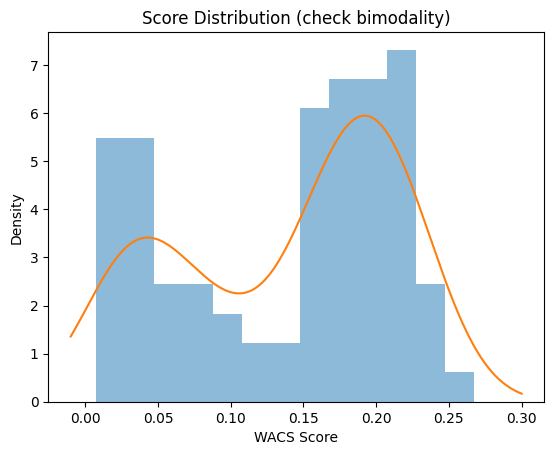

In [200]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
import json

with open("results/mfa/wacs.json", 'r') as fp:
    results = json.load(fp)


scores = list(results.values())
scores = np.array([sc['wacs'] for sc in scores if sc])
plt.figure()

# choose bin width
bin_width = 0.02

# compute bins from min/max
bins = np.arange(scores.min(), scores.max() + bin_width, bin_width)

plt.hist(scores, bins=bins, density=True, alpha=0.5)

# KDE curve
kde = gaussian_kde(scores)
x = np.linspace(-0.01, 0.3, 500)
plt.plot(x, kde(x))

plt.xlabel("WACS Score")
plt.ylabel("Density")
plt.title("Score Distribution (check bimodality)")

plt.show()

In [143]:
np.std(scores1)

np.float64(0.1079490620616965)

In [114]:
# 23 0.05
# 21 0.08
# 19 0.07
# 17 0.10
# 15 0.11
# 14 0.11
# 13 0.11
# 12 0.11
# 11 0.10
# 10 0.11
# 9 0.11
# 8 0.10
# 7 0.11
# 5 0.09
# 3 0.09

In [11]:
from eval_aligns import ForcedAlignEval, ForcedAlignEvalConfig
import os, librosa, numpy as np
from glob import glob
import random

cfg=ForcedAlignEvalConfig()
evaluator=ForcedAlignEval(cfg)

wav_root="buckeye_clean/wav"
tg_root="buckeye_clean/tg_VC_boundary//"

all_tgs=sorted(
    glob(os.path.join(tg_root,"**","*.TextGrid"),recursive=True)
)

pairs=[]

for tg_path in all_tgs:

    rel=os.path.relpath(tg_path,tg_root)

    wav_path=os.path.join(
        wav_root,
        os.path.splitext(rel)[0]+".wav"
    )

    if os.path.exists(wav_path):
        pairs.append((wav_path,tg_path))

random.shuffle(pairs)

print(f"found {len(pairs)} wav/tg pairs")

def audio_iter():

    for wav_path,_ in pairs:

        try:
            audio,_=librosa.load(
                wav_path,
                sr=16000,
                mono=True
            )

            yield audio.astype(np.float32)

        except Exception as e:
            print(wav_path,e)

def tg_iter():

    for _,tg_path in pairs:
        yield tg_path

results=evaluator.compute_metrics(
    audios=audio_iter(),
    tg_paths=tg_iter()
)


found 2935 wav/tg pairs


In [12]:
results

{'nmi': {'nmi': 0.3363807304903306,
  'cluster_entropy': 3.838995619530939,
  'cluster_entropy_norm': 0.9813325775958175,
  'label_entropy': 4.110995713290556,
  'label_entropy_norm': 0.8663971585002695,
  'mean_cluster_purity': 0.27001218436263313,
  'std_cluster_purity': 0.22135449034520036,
  'frames': 8640,
  'labels': 115,
  'clusters_used': 50},
 'wacs': {'positive': 0.543943187375553,
  'negative': 0.3851612878961232,
  'wacs': 0.15878189947942983,
  'positive_std': 0.09565340907697065,
  'negative_std': 0.07463366284452433,
  'cohen_d': 1.7836288042963717,
  'snr': 0.9324365517792523,
  'positive_pairs': 1916,
  'negative_pairs': 997,
  'positive_min': 0.2658818023541555,
  'positive_max': 0.8252652281313676,
  'negative_min': 0.17241171265901867,
  'negative_max': 0.6650936424539335,
  'vocab_size': 200}}

In [6]:
from eval_aligns import (
    ForcedAlignEval,
    ForcedAlignEvalConfig
)

import os
import json
import random
import librosa
import numpy as np

from glob import glob

N = 5

# ---------------------------------------------------------
# ONLY RUN MFCC
# ---------------------------------------------------------
MODEL_NAME = "mfcc"

# ---------------------------------------------------------
# PATHS
# ---------------------------------------------------------
wav_root = "buckeye_clean/wav"

tg_roots = [
    "tg",
    "tg_VC",
    "tg_SIL",
    "tg_SIL_boundary",
    "tg_VC_boundary",
    "tg_50",
    "tg_100",
    "tg_200",
    "tg_500",
    "tg_1000",
    "tg_2000"
]

# ---------------------------------------------------------
# LOAD PREVIOUS RESULTS
# ---------------------------------------------------------
out_path = "results/perturbation.json"

all_results = {}

try:

    with open(out_path, "r") as fp:

        old_results = json.load(fp)

    # ---------------------------------------------
    # previous file contains:
    # {
    #   "tg": [...],
    #   ...
    # }
    #
    # convert into:
    # {
    #   "facebook/mms-300m": {...},
    #   "mfcc": {...}
    # }
    # ---------------------------------------------
    if "facebook/mms-300m" not in old_results:

        all_results["facebook/mms-300m"] = old_results

    else:

        all_results = old_results

except:

    all_results = {}

# ---------------------------------------------------------
# PREPARE MFCC SLOT
# ---------------------------------------------------------
if MODEL_NAME not in all_results:
    all_results[MODEL_NAME] = {}

# ---------------------------------------------------------
# EVALUATOR
# ---------------------------------------------------------
cfg = ForcedAlignEvalConfig(
    model=MODEL_NAME
)

evaluator = ForcedAlignEval(cfg)

# ---------------------------------------------------------
# RUN
# ---------------------------------------------------------
print("\n" + "=" * 80)
print("MODEL:", MODEL_NAME)
print("=" * 80)

for tg_name in tg_roots:

    if tg_name in all_results[MODEL_NAME]:

        print("skipping:", tg_name)
        continue

    tg_root = f"buckeye_clean/{tg_name}"

    all_tgs = sorted(
        glob(
            os.path.join(
                tg_root,
                "**",
                "*.TextGrid"
            ),
            recursive=True
        )
    )

    pairs = []

    for tg_path in all_tgs:

        rel = os.path.relpath(
            tg_path,
            tg_root
        )

        wav_path = os.path.join(
            wav_root,
            os.path.splitext(rel)[0] + ".wav"
        )

        if os.path.exists(wav_path):

            pairs.append(
                (
                    wav_path,
                    tg_path
                )
            )

    print(
        tg_name,
        "pairs:",
        len(pairs)
    )

    runs = []

    # -----------------------------------------------------
    # repeated runs
    # -----------------------------------------------------
    for run in range(N):

        random.shuffle(pairs)

        def audio_iter():

            for wav_path, _ in pairs:

                try:

                    audio, _ = librosa.load(
                        wav_path,
                        sr=16000,
                        mono=True
                    )

                    yield audio.astype(
                        np.float32
                    )

                except Exception as e:

                    print(
                        wav_path,
                        e
                    )

        def tg_iter():

            for _, tg_path in pairs:
                yield tg_path

        metrics = evaluator.compute_metrics(
            audios=audio_iter(),
            tg_paths=tg_iter()
        )

        runs.append(metrics)

        print(
            tg_name,
            f"run {run+1}",
            "PCMI:",
            (
                metrics["nmi"]["nmi"]
                if metrics["nmi"]
                else None
            ),
            "WACS:",
            (
                metrics["wacs"]["wacs"]
                if metrics["wacs"]
                else None
            )
        )

    # -----------------------------------------------------
    # store
    # -----------------------------------------------------
    all_results[
        MODEL_NAME
    ][
        tg_name
    ] = runs

    # -----------------------------------------------------
    # save incrementally
    # -----------------------------------------------------
    os.makedirs(
        "results",
        exist_ok=True
    )

    with open(out_path, "w") as fp:

        json.dump(
            all_results,
            fp,
            indent=2
        )

    print(
        "saved:",
        out_path
    )

print("\nDONE")


MODEL: mfcc
tg pairs: 2935
tg run 1 PCMI: 0.2818483523174197 WACS: 0.009220296695362729
tg run 2 PCMI: 0.2880834857992406 WACS: 0.009895999634985775
tg run 3 PCMI: 0.28792473639517724 WACS: 0.009747535812606678
tg run 4 PCMI: 0.2800684110956472 WACS: 0.011061649927317174
tg run 5 PCMI: 0.29632422864979985 WACS: 0.01119598737371219
saved: results/perturbation.json
tg_VC pairs: 2935
tg_VC run 1 PCMI: 0.25468988617107224 WACS: 0.010688094245838275
tg_VC run 2 PCMI: 0.25720096136257553 WACS: 0.010692495806363445
tg_VC run 3 PCMI: 0.26358808429294855 WACS: 0.011161757027399077
tg_VC run 4 PCMI: 0.27081598466507073 WACS: 0.01037935997023598
tg_VC run 5 PCMI: 0.2598408658832343 WACS: 0.008565871255789226
saved: results/perturbation.json
tg_SIL pairs: 2935
tg_SIL run 1 PCMI: 0.28463106301514485 WACS: 0.010277972457179763
tg_SIL run 2 PCMI: 0.2750430665720603 WACS: 0.009386721803807285
tg_SIL run 3 PCMI: 0.2674351378642111 WACS: 0.008500934470548227
tg_SIL run 4 PCMI: 0.281484061221778 WACS: 0

## Layer tuning

In [11]:
from eval_aligns import ForcedAlignEval, ForcedAlignEvalConfig
import os, json, random, librosa, numpy as np
from glob import glob
from tqdm import tqdm

wav_root="buckeye_clean/wav"

tg_suffixes=[
    "tg",
    "tg_50",
    "tg_100",
    "tg_200",
    "tg_500",
    "tg_1000",
    "tg_2000"
]

all_results={}
models = ['facebook/wav2vec2-large-xlsr-53', 'facebook/mms-300m']
for model in models:
    print(model)
    all_results[model] = {}
    for layer in range(24):
        layer_key=f"layer_{layer}"
        print(layer_key)
        all_results[model][layer_key]={}
        cfg=ForcedAlignEvalConfig(
                    model=model,
                    layer_range=(layer,layer+1)
            )
        evaluator=ForcedAlignEval(cfg)
    
        for tg_name in tqdm(tg_suffixes):
    
            tg_root=f"buckeye_clean/{tg_name}"
    
            all_tgs=sorted(
                glob(
                    os.path.join(tg_root,"**","*.TextGrid"),
                    recursive=True
                )
            )
    
            pairs=[]
    
            for tg_path in all_tgs:
    
                rel=os.path.relpath(tg_path,tg_root)
    
                wav_path=os.path.join(
                    wav_root,
                    os.path.splitext(rel)[0]+".wav"
                )
    
                if os.path.exists(wav_path):
                    pairs.append((wav_path,tg_path))
    
            runs=[]
    
            for run in range(3):
    
                random.shuffle(pairs)
    
    
                def audio_iter():
    
                    for wav_path,_ in pairs:
    
                        try:
    
                            audio,_=librosa.load(
                                wav_path,
                                sr=16000,
                                mono=True
                            )
    
                            yield audio.astype(np.float32)
    
                        except Exception as e:
    
                            print(wav_path,e)
    
                def tg_iter():
    
                    for _,tg_path in pairs:
                        yield tg_path
    
                metrics=evaluator.compute_metrics(
                    audios=audio_iter(),
                    tg_paths=tg_iter()
                )
    
                runs.append(metrics)
    
            all_results[model][layer_key][tg_name]=runs

os.makedirs("results",exist_ok=True)

with open("results/layer_tuning.json","w") as fp:
    json.dump(all_results,fp,indent=2)

print("saved -> results/layer_tuning.json")

facebook/wav2vec2-large-xlsr-53
layer_0


100%|████████████████████████████████████████████| 7/7 [12:21<00:00, 105.86s/it]


layer_1


100%|████████████████████████████████████████████| 7/7 [12:37<00:00, 108.20s/it]


layer_2


...

layer_22


100%|█████████████████████████████████████████████| 7/7 [11:28<00:00, 98.37s/it]


layer_23


100%|█████████████████████████████████████████████| 7/7 [11:07<00:00, 95.35s/it]

saved -> results/layer_tuning.json


In [19]:
import json, numpy as np
from scipy.stats import linregress

with open("results/layer_tuning.json") as fp:
    results=json.load(fp)

aas_map={
    "tg":0,
    "tg_50":45,
    "tg_100":75,
    "tg_200":110,
    "tg_500":160,
    "tg_1000":190,
    "tg_2000":210
}

for model,model_data in results.items():

    nmi_scores=[]
    wacs_scores=[]

    for layer_key,layer_data in model_data.items():

        layer=int(layer_key.split("_")[-1])

        xs=[]
        nmis=[]
        wacss=[]

        for tg_name,aas in aas_map.items():

            if tg_name not in layer_data:
                continue

            runs=layer_data[tg_name]

            nmi_vals=[
                r["nmi"]["nmi"]
                for r in runs
                if r["nmi"] is not None
            ]

            wacs_vals=[
                r["wacs"]["wacs"]
                for r in runs
                if r["wacs"] is not None
            ]

            if len(nmi_vals)==0 or len(wacs_vals)==0:
                continue

            xs.append(aas)
            nmis.append(np.mean(nmi_vals))
            wacss.append(np.mean(wacs_vals))

        if len(xs)<3:
            continue

        # -------------------
        # NMI
        # -------------------
        res=linregress(xs,nmis)

        nmi_scores.append({
            "layer":layer,
            "slope":float(res.slope),
            "r2":float(res.rvalue**2),
            "score":float(abs(res.slope)*(res.rvalue**2)),
            "start":float(nmis[0]),
            "end":float(nmis[-1]),
            "drop":float(nmis[0]-nmis[-1])
        })

        # -------------------
        # WACS
        # -------------------
        res=linregress(xs,wacss)

        wacs_scores.append({
            "layer":layer,
            "slope":float(res.slope),
            "r2":float(res.rvalue**2),
            "score":float(abs(res.slope)*(res.rvalue**2)),
            "start":float(wacss[0]),
            "end":float(wacss[-1]),
            "drop":float(wacss[0]-wacss[-1])
        })

    nmi_top=sorted(
        nmi_scores,
        key=lambda x:x["score"],
        reverse=True
    )[:10]

    wacs_top=sorted(
        wacs_scores,
        key=lambda x:x["score"],
        reverse=True
    )[:10]

    print("\n"+"="*80)
    print(model)

    print("\nTop NMI layers")

    for x in nmi_top:

        print(
            f"layer={x['layer']} "
            f"score={x['score']:.6f} "
            f"slope={x['slope']:.6f} "
            f"r2={x['r2']:.4f} "
            f"drop={x['drop']:.4f}"
        )

    print("\nTop WACS layers")

    for x in wacs_top:

        print(
            f"layer={x['layer']} "
            f"score={x['score']:.6f} "
            f"slope={x['slope']:.6f} "
            f"r2={x['r2']:.4f} "
            f"drop={x['drop']:.4f}"
        )


facebook/wav2vec2-large-xlsr-53

Top NMI layers
layer=14 score=0.000889 slope=-0.001028 r2=0.8651 drop=0.2469
layer=16 score=0.000879 slope=-0.001033 r2=0.8510 drop=0.2403
layer=17 score=0.000865 slope=-0.001044 r2=0.8284 drop=0.2485
layer=4 score=0.000861 slope=-0.001043 r2=0.8258 drop=0.2453
layer=9 score=0.000853 slope=-0.001045 r2=0.8164 drop=0.2543
layer=5 score=0.000843 slope=-0.001013 r2=0.8321 drop=0.2456
layer=19 score=0.000843 slope=-0.001036 r2=0.8133 drop=0.2466
layer=8 score=0.000837 slope=-0.001020 r2=0.8205 drop=0.2410
layer=12 score=0.000829 slope=-0.000985 r2=0.8412 drop=0.2325
layer=20 score=0.000828 slope=-0.001004 r2=0.8249 drop=0.2417

Top WACS layers
layer=7 score=0.000577 slope=-0.000650 r2=0.8875 drop=0.1431
layer=11 score=0.000567 slope=-0.000635 r2=0.8942 drop=0.1393
layer=9 score=0.000562 slope=-0.000658 r2=0.8549 drop=0.1434
layer=10 score=0.000562 slope=-0.000643 r2=0.8735 drop=0.1438
layer=13 score=0.000554 slope=-0.000631 r2=0.8786 drop=0.1396
layer=6 sc

## K-means tuning

In [1]:
from eval_aligns import ForcedAlignEval, ForcedAlignEvalConfig
import os, json, random, librosa, numpy as np
from glob import glob
from tqdm import tqdm

wav_root="buckeye_clean/wav"

tg_suffixes=[
    "tg",
#    "tg_50",
    "tg_100",
#    "tg_200",
    "tg_500",
#    "tg_1000",
    "tg_2000"
]

# all_results={}
with open("results/kmeans_tuning.json", 'r') as fp:
    all_results=json.load(fp)
models = ['facebook/wav2vec2-large-xlsr-53']# ,'facebook/mms-300m']
for model in models:
    print(model)
    all_results[model] = {}
    for k in [25, 50, 100, 150, 200]:
        n_clusters=f"n_clusters_{k}"
        print(n_clusters)
        all_results[model][n_clusters]={}
        cfg=ForcedAlignEvalConfig(
                    model=model,
                    n_clusters=k,
            )
        evaluator=ForcedAlignEval(cfg)
    
        for tg_name in tqdm(tg_suffixes):
    
            tg_root=f"buckeye_clean/{tg_name}"
    
            all_tgs=sorted(
                glob(
                    os.path.join(tg_root,"**","*.TextGrid"),
                    recursive=True
                )
            )
    
            pairs=[]
    
            for tg_path in all_tgs:
    
                rel=os.path.relpath(tg_path,tg_root)
    
                wav_path=os.path.join(
                    wav_root,
                    os.path.splitext(rel)[0]+".wav"
                )
    
                if os.path.exists(wav_path):
                    pairs.append((wav_path,tg_path))
    
            runs=[]
    
            for run in range(3):
    
                random.shuffle(pairs)
    
    
                def audio_iter():
    
                    for wav_path,_ in pairs:
    
                        try:
    
                            audio,_=librosa.load(
                                wav_path,
                                sr=16000,
                                mono=True
                            )
    
                            yield audio.astype(np.float32)
    
                        except Exception as e:
    
                            print(wav_path,e)
    
                def tg_iter():
    
                    for _,tg_path in pairs:
                        yield tg_path
    
                metrics=evaluator.compute_metrics(
                    audios=audio_iter(),
                    tg_paths=tg_iter()
                )
    
                runs.append(metrics)
    
            all_results[model][n_clusters][tg_name]=runs

os.makedirs("results",exist_ok=True)

with open("results/kmeans_tuning.json","w") as fp:
    json.dump(all_results,fp,indent=2)

print("saved -> results/kmeans_tuning.json")

/localscratch/nnsfn01/anaconda3/envs/north_caucasus/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


facebook/wav2vec2-large-xlsr-53
n_clusters_25


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [08:34<00:00, 128.69s/it]


n_clusters_50


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [08:24<00:00, 126.05s/it]


...

n_clusters_150


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [06:45<00:00, 101.47s/it]


n_clusters_200


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [08:44<00:00, 131.04s/it]

saved -> results/kmeans_tuning.json


## Multilingual eval

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "2"
os.environ["OMP_NUM_THREADS"] = "2"

from datasets import load_dataset, DownloadConfig
from itertools import islice

download_config = DownloadConfig(
    local_files_only=True,
    cache_dir=".cache",   # optional
)

def batch_iterator(iterable, batch_size):
    iterator = iter(iterable)

    while True:
        batch = list(islice(iterator, batch_size))

        if not batch:
            break

        yield batch

LANGS = ['af_za', 'am_et', 'ar_eg', 'ast_es', 'az_az', 'be_by', 'bg_bg', 'bn_in', 'ca_es', 'ceb_ph', 'ckb_iq', 'cmn_hans_cn', 'cs_cz', 'cy_gb', 'da_dk', 'de_de', 'el_gr', 'en_us', 'es_419', 'et_ee', 'fa_ir', 'ff_sn', 'fi_fi', 'fr_fr', 'ga_ie', 'gl_es', 'ha_ng', 'he_il', 'hi_in', 'hr_hr', 'hu_hu', 'hy_am', 'id_id', 'it_it', 'ja_jp', 'jv_id', 'ka_ge', 'kk_kz', 'km_kh', 'kn_in', 'ko_kr', 'ky_kg', 'lg_ug', 'lo_la', 'lt_lt', 'lv_lv', 'mi_nz', 'mk_mk', 'ml_in', 'mn_mn', 'mr_in', 'ms_my', 'mt_mt', 'my_mm', 'nb_no', 'ne_np', 'nl_nl', 'ny_mw', 'om_et', 'or_in', 'pa_in', 'pl_pl', 'ps_af', 'pt_br', 'ro_ro', 'ru_ru', 'sl_si', 'sn_zw', 'so_so', 'sv_se', 'sw_ke', 'ta_in', 'te_in', 'tg_tj', 'th_th', 'tr_tr', 'uk_ua', 'ur_pk', 'uz_uz', 'vi_vn', 'wo_sn', 'xh_za', 'yo_ng', 'yue_hant_hk', 'zu_za']

/localscratch/nnsfn01/anaconda3/envs/north_caucasus/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from eval_aligns import ForcedAlignEval, ForcedAlignEvalConfig
from scipy.io import wavfile
from tqdm import tqdm
import numpy as np
import os, json, gc
# ---------------------------------------------------------
# AAS
# ---------------------------------------------------------
from difflib import SequenceMatcher
import numpy as np
import textgrid

def load_tg(path,word_tier="words",phone_tier="phones"):
    tg=textgrid.TextGrid.fromFile(path)

    def tier2list(name):
        tier=[t for t in tg.tiers if t.name==name][0]
        out=[]
        for x in tier:
            out.append({
                "start":float(x.minTime),
                "end":float(x.maxTime),
                "text":x.mark
            })
        return out

    return tg.maxTime,tier2list(word_tier),tier2list(phone_tier)
    
def compute_aas(gold,pred):

    def align_and_score(g,p):

        gl=[x["text"] for x in g]
        pl=[x["text"] for x in p]

        sm=SequenceMatcher(a=gl,b=pl)

        errs=[]

        for tag,i1,i2,j1,j2 in sm.get_opcodes():

            if tag=="equal":

                for gx,px in zip(g[i1:i2],p[j1:j2]):

                    e=(
                        abs(gx["start"]-px["start"])+
                        abs(gx["end"]-px["end"])
                    )/2

                    errs.append(e)

            else:
                # insertion/deletion/substitution
                bad=g[i1:i2]

                for x in bad:
                    errs.append(x["end"]-x["start"])

        if len(errs)==0:
            return None, None
        
        return 1000*np.mean(errs), np.array(errs)

    _,gw,gp=load_tg(gold)
    _,pw,pp=load_tg(pred)

    waas, errs =align_and_score(gw,pw)
    paas, _ =align_and_score(gp,pp)

    return {
        "word_aas_ms":round(float(waas),3) if waas is not None else None,
        "phone_aas_ms":round(float(paas),3) if paas is not None else None,
    }
    
# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
LANGS=LANGS
DORECO_LANGS = sorted(
        d
        for d in os.listdir("doreco_dataset")
        if os.path.isdir(os.path.join("doreco_dataset", d))
        and not d.startswith(".")
    )

ALIGN_DIRS=[
#    "alignments/qwen3-FA/",
#    "alignments/mms-300m-ipa/",
#    "alignments/random/",
#    "alignments/mfa/",
#    "alignments/w2v2-lv-60-espeak-ipa/",
    "alignments/gold_doreco",
    "alignments/random_doreco/",
    "alignments/mms-300m-ipa-doreco-SIL/",
    "alignments/mms-300m-ipa-doreco/",
#    "alignments/w2v2-lv-60-espeak-ipa-doreco-SIL/",
#    "alignments/w2v2-lv-60-espeak-ipa-doreco/",
]

MODELS=[
    "facebook/mms-300m",
    "facebook/wav2vec2-large-xlsr-53"
]

SAMPLE_SIZE=250


# ---------------------------------------------------------
# EVALUATORS
# ---------------------------------------------------------
evaluators={}

for model_name in MODELS:

    cfg=ForcedAlignEvalConfig(
        model=model_name,
    )

    evaluators[model_name]=ForcedAlignEval(cfg)

# ---------------------------------------------------------
# RESULTS STRUCTURE
# results[align_dir][lang][model]
# ---------------------------------------------------------
results={}

for align_dir in ALIGN_DIRS:

    results[align_dir]={}

# ---------------------------------------------------------
# MATERIALIZE ONE LANGUAGE
# ---------------------------------------------------------
def materialize_language(lang):

    ds=load_dataset(
        "fleurs",
        lang,
        split="test",
        streaming=True,
        download_config=download_config,
        trust_remote_code=True
    )

    ds=ds.shuffle(buffer_size=500).take(SAMPLE_SIZE)

    items=[]

    for x in ds:

        try:

            items.append({
                "audio":x["audio"]["array"][:360000].astype(np.float32),
                "wav_file":os.path.basename(x["audio"]["path"])
            })

        except Exception as e:

            print(lang,e)

    return items

def materialize_doreco_language(lang, root):

    audio_dir = os.path.join(root, lang, "audio")

    items = []

    for wav_file in sorted(os.listdir(audio_dir)):

        if not wav_file.endswith(".wav"):
            continue

        wav_path = os.path.join(audio_dir, wav_file)

        sr, audio = wavfile.read(wav_path)

        if audio.dtype != np.float32:
            audio = audio.astype(np.float32)

            if np.issubdtype(audio.dtype, np.integer):
                audio /= np.iinfo(audio.dtype).max

        items.append(
            {
                "audio": audio,
                "wav_file": wav_file,
            }
        )

    return items
    
# ---------------------------------------------------------
# RESOLVE TEXTGRIDS
# ---------------------------------------------------------
def resolve_tg_paths(items,align_dir,lang, gold=False):

    if not gold:
        tg_roots=[os.path.join(align_dir,lang)]
    else:
        tg_roots=[os.path.join(align_dir,lang,'gold')]

    if "mfa" in align_dir:

        tg_root=tg_roots[0]

        tg_roots=[
            os.path.join(tg_root,f)
            for f in os.listdir(tg_root)
            if os.path.exists(os.path.join(tg_root,f))
        ]

    resolved=[]

    for item in items:

        found=None

        for tg_root in tg_roots:

            tg_path=os.path.join(
                tg_root,
                os.path.splitext(item["wav_file"])[0]+".TextGrid"
            )

            if os.path.exists(tg_path):

                found=tg_path
                break

        resolved.append(found)

    return resolved

# ---------------------------------------------------------
# GENERATORS
# ---------------------------------------------------------
def audio_iter(items):

    for x in items:
        yield x["audio"]

def tg_iter(tg_paths):

    for tg in tg_paths:
        yield tg



for lang in tqdm(LANGS,desc="languages"):
    if not os.path.exists(os.path.join(align_dir, lang)):
        continue
    # -------------------------------------
    # materialize ONCE for this language
    # -------------------------------------
    items=materialize_language(lang)

    if len(items)==0:
        continue

    # -------------------------------------
    # evaluate all alignment dirs
    # and all embedding models
    # -------------------------------------
    for align_dir in ALIGN_DIRS:
        if 'doreco' in align_dir:
            continue

        results[align_dir][lang]={}

        tg_paths=resolve_tg_paths(
            items,
            align_dir,
            lang
        )

        for model_name,evaluator in evaluators.items():

            metrics=evaluator.compute_metrics(
                audios=audio_iter(items),
                tg_paths=tg_iter(tg_paths)
            )

            results[align_dir][lang][model_name]=metrics

            print(
                lang,
                os.path.basename(align_dir.rstrip("/")),
                model_name.split("/")[-1],
                metrics["nmi"]["nmi"] if metrics["nmi"] else None,
                metrics["wacs"]["wacs"] if metrics["wacs"] else None
            )


    # -------------------------------------
    # free memory before next language
    # -------------------------------------
    del items
    gc.collect()

for lang in tqdm(DORECO_LANGS, desc="languages"):

    items = materialize_doreco_language(
        lang,
        "alignments/random_doreco",
    )

    if len(items) == 0:
        continue

    # -------------------------------------
    # evaluate all alignment dirs
    # and all embedding models
    # -------------------------------------
    for align_dir in ALIGN_DIRS:
        if 'doreco' not in align_dir:
            continue

        results[align_dir][lang]={}

        if 'gold' not in align_dir:
            tg_paths=resolve_tg_paths(
                items,
                align_dir,
                lang
            )
        else:
            tg_paths = resolve_tg_paths(items, "alignments/random_doreco", lang, gold=True)

        for model_name,evaluator in evaluators.items():

            metrics=evaluator.compute_metrics(
                audios=audio_iter(items),
                tg_paths=tg_iter(tg_paths)
            )
            gold_tg_paths = resolve_tg_paths(items, "alignments/random_doreco", lang, gold=True)
            
            aas_scores = []
            
            for gold_tg, pred_tg in zip(gold_tg_paths, tg_paths):
                
                aas_scores.append(compute_aas(gold_tg, pred_tg))

            
            metrics["aas"] = {
                "word_aas_ms": float(
                    np.mean(
                        [
                            x["word_aas_ms"]
                            for x in aas_scores
                            if x["word_aas_ms"] is not None
                        ]
                    )
                ),
                "phone_aas_ms": float(
                    np.mean(
                        [
                            x["phone_aas_ms"]
                            for x in aas_scores
                            if x["phone_aas_ms"] is not None
                        ]
                    )
                ),
            }

            results[align_dir][lang][model_name]=metrics
            print(
                lang,
                os.path.basename(align_dir.rstrip("/")),
                model_name.split("/")[-1],
                metrics["nmi"]["nmi"] if metrics["nmi"] else None,
                metrics["wacs"]["wacs"] if metrics["wacs"] else None,
                metrics["aas"]
            )


    # -------------------------------------
    # free memory before next language
    # -------------------------------------
    del items
    gc.collect()


# -----------------------------------------------------
# SAVE PER ALIGNMENT DIRECTORY
# -----------------------------------------------------
for align_dir in ALIGN_DIRS:

    align_name=os.path.basename(
        align_dir.rstrip("/")
    )

    os.makedirs(os.path.join("results", align_name), exist_ok=True)
    out_path=os.path.join( "results",
        align_name,
        f"alignment_results.json"
    )

    with open(out_path,"w") as fp:

        json.dump(
            results[align_dir],
            fp,
            indent=2
        )

    print(f"saved -> {out_path}")

## ASR eval

In [9]:
import os
import json
import pandas as pd
import numpy as np
from glob import glob
from tqdm import tqdm
from jiwer import wer, cer


RESULTS_ROOT="results"

# ---------------------------------------------------------
# FIND MODELS WITH predictions.tsv
# ---------------------------------------------------------
model_paths=["models/mms-300m-ipa", "models/w2v2-lv-60-espeak-ipa"]


models=[
    os.path.basename(x)
    for x in model_paths
]


# ---------------------------------------------------------
# LOAD PREDICTIONS
# ---------------------------------------------------------
pred_tables={}

for model,path in zip(models,model_paths):

    pred_path=os.path.join(path,"predictions.tsv")

    df=pd.read_csv(
        pred_path,
        sep="\t"
    )

    df["id"]=df["id"].astype(str)
    df["filename"]=df["filename"].astype(str)

    pred_tables[model]=df

# ---------------------------------------------------------
# RESULTS
# ---------------------------------------------------------
results={
    model:{} for model in models
}

# ---------------------------------------------------------
# LOOP LANGS
# ---------------------------------------------------------
for lang in tqdm(LANGS):

    # -----------------------------------------
    # materialize dataset once
    # -----------------------------------------
    ds=load_dataset(
        "fleurs",
        lang,
        split="test",
        streaming=True,
        trust_remote_code=True,
        download_config=download_config,
    )

    data=[]

    for x in ds:

        data.append({
            "id":str(x["id"]),
            "filename":os.path.basename(
                x["audio"]["path"]
            ),
            "ipa":x["ipa"].replace("<unk>","!")
        })

    gt_df=pd.DataFrame(data)


    # -----------------------------------------
    # evaluate all models
    # -----------------------------------------
    for model in models:

        df=pred_tables[model]

        pred_df=df[
            df["lang"]==lang
        ][[
            "id",
            "filename",
            "predicted_ipa"
        ]]

        if len(pred_df)==0:
            continue

        merged=gt_df.merge(
            pred_df,
            on=["id","filename"],
            how="inner"
        )

        if len(merged)==0:
            continue

        wers=[]
        cers=[]

        for _,row in merged.iterrows():

            ref=str(row["ipa"]).strip()
            hyp=str(row["predicted_ipa"]).strip()

            try:

                wers.append(
                    wer(ref,hyp)
                )

                cers.append(
                    cer(ref,hyp)
                )

            except Exception:
                pass

        if len(wers)==0:
            continue

        results[model][lang]={
            "wer":np.mean(wers),
            "cer":np.mean(cers),
            "wer_std":np.std(wers),
            "cer_std":np.std(cers),
            "samples":len(wers),
        }

# ---------------------------------------------------------
# SAVE
# ---------------------------------------------------------
for model in models:

    out_path=os.path.join(
        RESULTS_ROOT,
        model,
        "asr.json"
    )

    with open(out_path,"w") as fp:

        json.dump(
            results[model],
            fp,
            indent=4,
            ensure_ascii=False
        )

    print(f"saved {out_path}")

models found:
['mms-300m-ipa', 'w2v2-lv-60-espeak-ipa']


100%|███████████████████████████████████████████| 85/85 [20:08<00:00, 14.22s/it]

saved results/mms-300m-ipa/asr.json
saved results/w2v2-lv-60-espeak-ipa/asr.json


In [1]:
import os
import json
import pandas as pd
import numpy as np
from tqdm import tqdm
from jiwer import wer, cer

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
RESULTS_ROOT = "results"

model_paths = [
    "results/mms-300m-ipa-doreco"
]

# ---------------------------------------------------------
# FIND MODELS
# ---------------------------------------------------------
models = [
    os.path.basename(path.rstrip("/"))
    for path in model_paths
]

results = {}

# ---------------------------------------------------------
# EVALUATE
# ---------------------------------------------------------
for model, path in tqdm(
    list(zip(models, model_paths)),
    desc="Models"
):

    pred_path = os.path.join(path, "predictions.tsv")

    if not os.path.exists(pred_path):
        print(f"Missing: {pred_path}")
        continue

    df = pd.read_csv(
        pred_path,
        sep="\t",
        keep_default_na=False,
    )

    model_results = {}

    for lang in sorted(df["lang"].unique()):

        lang_df = df[df["lang"] == lang]

        wers = []
        cers = []

        for _, row in lang_df.iterrows():

            ref = str(row["gold_ipa"]).strip()
            hyp = str(row["predicted_ipa"]).strip()

            if not ref:
                continue

            try:
                wers.append(wer(ref, hyp))
                cers.append(cer(ref, hyp))
            except Exception:
                pass

        if len(wers) == 0:
            continue

        model_results[lang] = {
            "wer": float(np.mean(wers)),
            "cer": float(np.mean(cers)),
            "wer_std": float(np.std(wers)),
            "cer_std": float(np.std(cers)),
            "samples": len(wers),
        }

    results[model] = model_results

# ---------------------------------------------------------
# SAVE
# ---------------------------------------------------------
for model in models:

    out_dir = os.path.join(RESULTS_ROOT, model)
    os.makedirs(out_dir, exist_ok=True)

    out_path = os.path.join(
        out_dir,
        "asr.json"
    )

    with open(out_path, "w", encoding="utf-8") as fp:
        json.dump(
            results[model],
            fp,
            indent=4,
            ensure_ascii=False
        )

    print(f"saved {out_path}")

Models: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.91s/it]

saved results/mms-300m-ipa-doreco/asr.json
